In [ ]:
library(DESeq2)

In [1]:
library(tidyverse)

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
library(ggrastr)
library(ggpubr)
library(ggthemes)

In [ ]:
library(pheatmap)

In [ ]:
library(org.Hs.eg.db)

In [ ]:
library(clusterProfiler)

In [2]:
phe <-read.table('phe_plusTF_footprint.txt',header=T)

In [3]:
phe  %>% count(footprint)

footprint,n
<chr>,<int>
C2,18
C3,20


In [4]:
rownames(phe) <- phe$name

In [5]:
head(phe)

,name,cluster,tcga,survival,MCO,ATAC,status,footprint,alltf
,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
U3008,U3008,3,CL,38,1,C2,2,C2,C3
U3013,U3013,2,PN,122,1,C3,2,C3,C3
U3020,U3020,3,MS,160,2,C3,2,C3,C3
U3024,U3024,2,MS,170,2,C2,2,C2,C2
U3027,U3027,3,MS,766,2,C3,2,C3,C3
U3031,U3031,2,MS,468,3,C2,2,C2,C2


In [22]:
data_raw = readRDS('data_filtered_raw.Rds')

In [23]:
deseq <- function(data_for_compare,coldata_for_compare){
 
    dds_compare <- DESeqDataSetFromMatrix(data_for_compare, coldata_for_compare, design= ~ footprint)
    dds_compare <- DESeq(dds_compare)
    res = results(dds_compare)
    res = res[order(res$pvalue),]
    diff_res <- subset(res, padj < 0.05 & abs(log2FoldChange) > log2(1.5))
    diff = as.data.frame(diff_res)
    allres = as.data.frame(res)

    diff_name=rownames(diff)
    all_name=rownames(allres)
    compare <- mcols(res)$description[2] %>% strsplit(split = ":") %>% .[[1]] %>% .[2]
    compare2 <-compare %>% strsplit(split="footprint ")%>% .[[1]] %>% .[2] %>% strsplit(split=" vs ") %>% .[[1]] 
    
    diff$category = NA
    diff[diff$log2FoldChange>0,]$category = compare2[1]
    diff[diff$log2FoldChange<0,]$category = compare2[2]
    allres <- allres[!is.na(allres$padj),]
    allres$category = NA
    allres[allres$log2FoldChange>0,]$category = compare2[1]
    allres[allres$log2FoldChange<0,]$category = compare2[2]
    
    return(list(all=allres,diff=diff,dds=dds_compare))
}

In [7]:
plot_valcano <- function(mydata){
    
    mydata$logP <- -log10(mydata$padj)
    mydata %>% mutate(group = case_when(padj<=0.05&log2FoldChange>log2(1.5) ~ "C3", 
                                                  padj<=0.05&log2FoldChange<(-log2(1.5)) ~ "C2",
                                                  padj>0.05|abs(log2FoldChange)<log2(1.5) ~"NoSig" )) -> mydata
    mytable <- table(mydata$group)
    p_high <- ggscatter(mydata, x = "log2FoldChange", y = "logP", color = "group", 
            palette = c("#CA0F1F","#3571B0","#BBBBBB"), size = 1, ## blue, grey,red 
            xlab = "log2FoldChange", ylab = "-log10(Adjust P-value)")+xlim(-3,3)+
    theme_base()+geom_hline(yintercept = -log10(0.05), linetype="dashed")+ylim(0,20)+
    geom_vline(xintercept = c(-log2(1.5),log2(1.5)), linetype="dashed")+
    annotate("text", x = 2, y = 15, label = mytable[2])+ 
    annotate("text", x = -2, y = 15, label = mytable[1])
    p <- rasterize(p_high,dpi=400)
    return(p)
}


In [46]:
head(data_raw)

,U3008_rep1,U3008_rep2,U3013_rep1,U3013_rep2,U3031_rep1,U3031_rep2,U3039_rep1,U3039_rep2,U3073_rep1,U3073_rep2,U3078_rep1,U3078_rep2,U3118_rep1,U3118_rep2,U3121_rep1,U3121_rep2
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A1BG,208,304,534,538,154,328,197,174,140,292,263,250,84,73,566,602
A1BG-AS1,72,111,315,270,70,115,108,112,31,35,91,109,93,42,189,143
A1CF,1,0,0,1,2,1,0,1,4,1,0,0,0,0,0,1
A2M,16164,10866,24286,27990,9588,5641,4941,1670,1352,1088,7507,9174,5533,1302,7157,4621
A2M-AS1,5,6,21,17,2,4,22,45,8,10,32,23,4,0,6,3
A2ML1,13,15,2,1,0,1,1,0,0,0,1,1,18,2,9,0


### differential

In [26]:
data_raw %>% colnames()%>% str_split(.,"_") %>% map_chr(first) %>% phe[.,] %>% dplyr::select(name,footprint) -> group_info

In [27]:
rownames(group_info) <- colnames(data_raw)

In [ ]:
group_info %>% count(footprint)

In [29]:
group_info %>% filter(footprint=="C2") %>% rownames() ->C2_names
group_info %>% filter(footprint=="C3") %>% rownames() ->C3_names

In [8]:
C2_names

[1] "U3008_rep1" "U3008_rep2" "U3031_rep1" "U3031_rep2" "U3073_rep1"
[6] "U3073_rep2"

In [9]:
C3_names

[1] "U3013_rep1" "U3013_rep2" "U3039_rep1" "U3039_rep2" "U3078_rep1"
 [6] "U3078_rep2" "U3118_rep1" "U3118_rep2" "U3121_rep1" "U3121_rep2"

In [ ]:
res <- deseq(data_raw,group_info)

In [8]:
p_valcano <- plot_valcano(res$all)

Warning message:
“Removed 950 rows containing missing values or values outside the scale range
(`geom_point()`).”


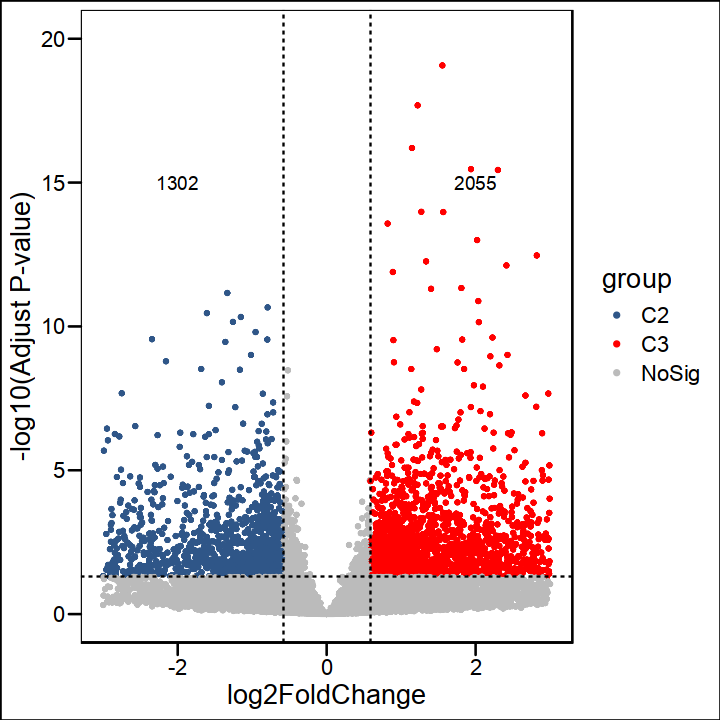

In [7]:
options(repr.plot.height=6,repr.plot.width=6)
p_valcano

In [8]:
ggsave(filename = "Volcano.RNAseq_valcano.pdf" ,plot =p_valcano,width = 6,height = 6 )

Warning message:
“Removed 950 rows containing missing values or values outside the scale range
(`geom_point()`).”


### GO

In [34]:
library(org.Hs.eg.db)

In [11]:
library(RColorBrewer)
get_plot <- function(C1_go,C2_go){
    C1_go %>% as.data.frame()  -> C1_temp
    C2_go %>% as.data.frame()  -> C2_temp
    C1_temp  %>% select(Description,GeneRatio,p.adjust,Count) %>% 
        mutate(group = "mGC1") -> C1_temp2
    C2_temp  %>% select(Description,GeneRatio,p.adjust,Count) %>% 
        mutate(group = "mGC2") -> C2_temp2
    
    if(nrow(C1_temp2)>20){
        C1_temp2 = C1_temp2[1:20,]
    }else if(nrow(C1_temp2)>0){
        C1_temp2 = C1_temp2[1:nrow(C1_temp2),]
    }else{
        C1_temp2 = C1_temp
    }
            
    if(nrow(C2_temp2)>20){
        C2_temp2 = C2_temp2[1:20,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }
    
    rbind(C1_temp2,C2_temp2) -> C1_C2_C3_comb
    
    C1_C2_C3_comb$Description  <- factor(C1_C2_C3_comb$Description,levels = unique(C1_C2_C3_comb  %>% arrange((Count)) %>% .[,1]))

        
    mat <- C1_C2_C3_comb %>%
      select(Description, group, p.adjust) %>%
      pivot_wider(names_from = group, values_from = p.adjust, values_fill = 1) %>%
      column_to_rownames("Description") %>%
      as.matrix()   
    row_dist <- dist(mat)
        row_clust <- hclust(row_dist)
        row_order <- row_clust$order
        description_ordered <- rownames(mat)[row_order]
    C1_C2_C3_comb$Description <- factor(C1_C2_C3_comb$Description, levels = description_ordered)

    p <- ggplot(data = C1_C2_C3_comb) + 
      geom_point(aes(x = group, y = Description, size = Count, color = p.adjust)) + 
      theme(panel.background = element_rect(fill = NA),
            panel.grid.major.y = element_line(color = 'gray', linetype = 'dashed'),
            axis.text = element_text(color = 'black'),
            panel.border = element_rect(fill = NA, color = 'black')) +
      geom_vline(xintercept = 0) +
      ylab('') + xlab('') + 
      theme(axis.text.y = element_text(size = 11)) +
      scale_colour_gradientn(colors = colorRampPalette(c("red", "blue"))(80))
    return(p)
}

In [37]:
DoGO <- function(data){
    gene_id = data$ENTREZID
    data_go <- enrichGO(gene = 
                             gene_id,
                             OrgDb = org.Hs.eg.db,
                             ont = "BP",
                             pAdjustMethod = "BH",
                             qvalueCutoff = 0.05,
                             pvalueCutoff = 0.05,
                             readable = TRUE
                        )
    return(data_go)
}

In [38]:
DoKEGG <- function(data){
    gene_id = data$ENTREZID
    data_kegg <- enrichKEGG(gene        = gene_id,
                         organism     = 'hsa',
                          qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [39]:
res$diff  %>% filter(category=='C2')  %>% rownames() -> C2geneid
res$diff  %>% filter(category=='C3')  %>% rownames() -> C3geneid

In [ ]:
C2geneid = bitr(c(C2geneid), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")
C3geneid = bitr(c(C3geneid), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

In [41]:
res$all  %>% saveRDS("res.Rds")

In [52]:
length(C2geneid$ENTREZID)

[1] 1384

In [53]:
length(C3geneid$ENTREZID)

[1] 2101

In [42]:
C2_GO <- DoGO(C2geneid)

In [43]:
C3_GO <- DoGO(C3geneid)

In [ ]:
C2_KEGG <- DoKEGG(C2geneid)
C3_KEGG <- DoKEGG(C3geneid)

In [62]:
saveRDS(C2_KEGG,"C2_KEGG.FC1.5.Rds")
saveRDS(C3_KEGG,"C3_KEGG.FC1.5.Rds")

In [12]:
C2C3_GO_bubble <- get_plot(C2_GO,C3_GO)

In [13]:
C2C3_KEGG_bubble <- get_plot(C2_KEGG,C3_KEGG)

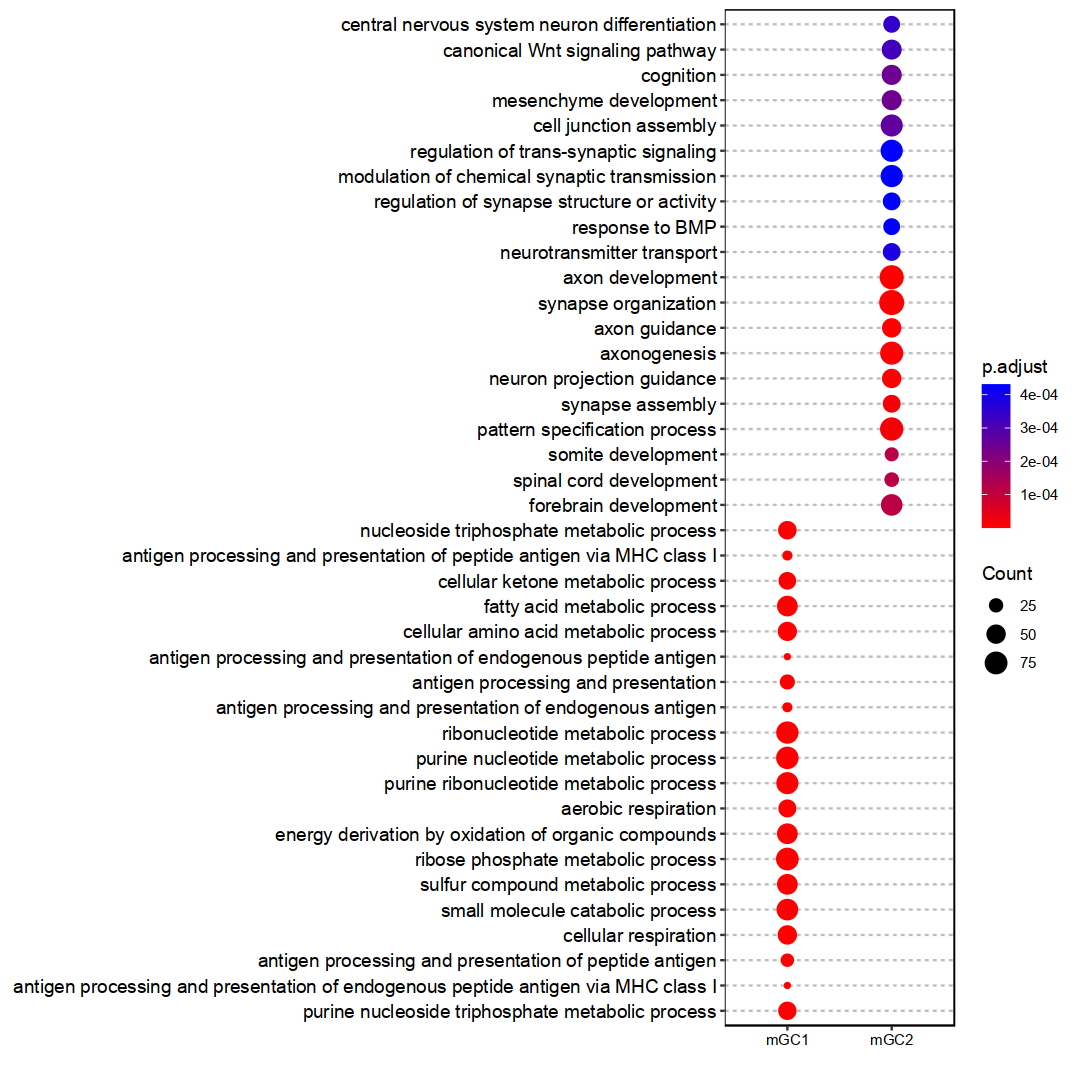

In [14]:
options(repr.plot.height=9,repr.plot.width=9)
C2C3_GO_bubble

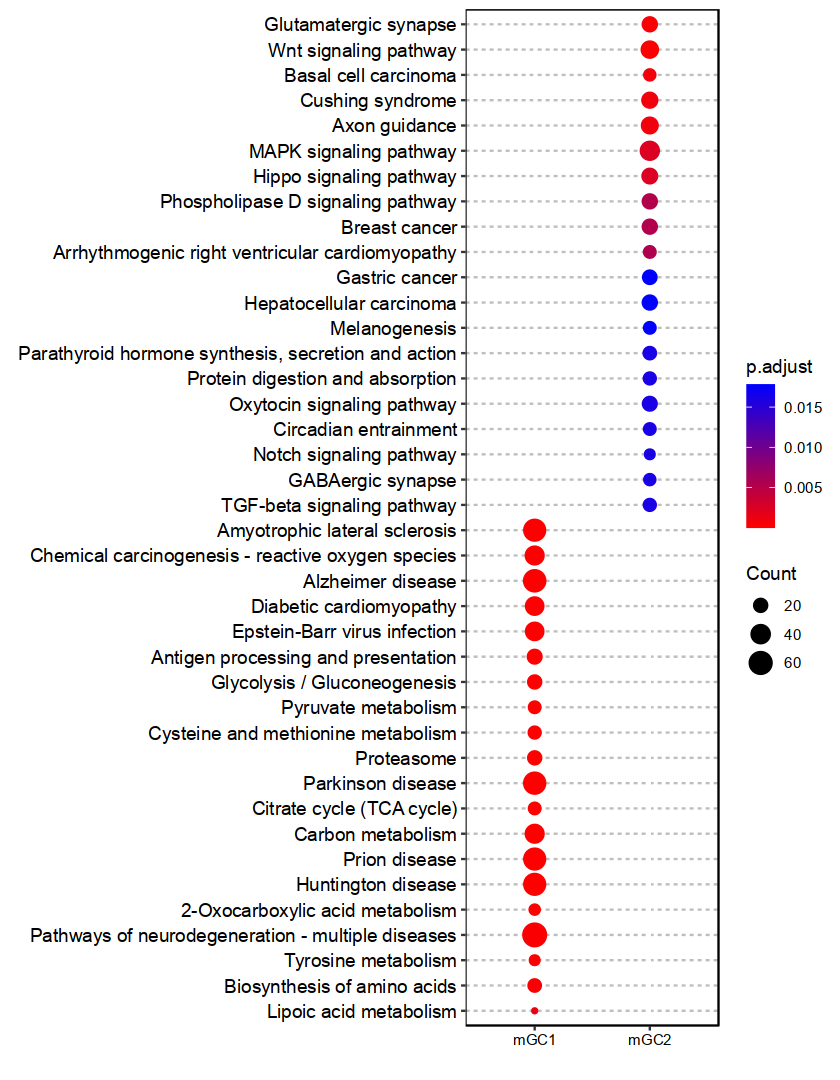

In [15]:
options(repr.plot.height=9,repr.plot.width=7)
C2C3_KEGG_bubble

In [16]:
ggsave(filename = "C2C3_RNA-seq_GO_bubble.pdf" ,plot =C2C3_GO_bubble,width = 9,height = 9 )
ggsave(filename = "C2C3_RNA-seq_KEGG_bubble.pdf" ,plot =C2C3_KEGG_bubble,width = 7,height = 9 )

In [ ]:
library(simplifyEnrichment)

In [43]:
active_mat_C2 = GO_similarity(C2_GO %>% as.data.frame() %>% rownames(),ont="BP")
active_mat_C3 = GO_similarity(C3_GO %>% as.data.frame() %>% rownames(),ont="BP")

In [44]:
pdf(file ="GO_simplify_C2_heatmap.pdf" ,width = 9,height = 6)
df_act_C2 = simplifyGO(active_mat_C2)
dev.off()

Cluster 424 terms by 'binary_cut'...
 4 clusters, used 1.326875 secs.

Perform keywords enrichment for 4 GO lists...



png 
  2

In [45]:
pdf(file ="GO_simplify_C3_heatmap.pdf" ,width = 9,height = 6)
df_act_C3 = simplifyGO(active_mat_C3)
dev.off()

Cluster 234 terms by 'binary_cut'...
 11 clusters, used 0.6705 secs.

Perform keywords enrichment for 9 GO lists...



png 
  2

### check genes

In [53]:
glycogenes <- c('HK1','HK2','HK3', 'GCK','GPI','PFKFB2','PFKFB3','PFKM','PFKL','PFKP','ALDOA', 
           'ALDOB','ALDOC','TPI1','GAPDH','PGK1','PGAM1','PGAM2','PGAM4',
           'ENO1', 'ENO2', 'ENO3','PKM','PKLR','LDHA','PDK1')

Fattygenes <- c("ACSL4", "ACSL1", "ACSL3", "ACSL5", "ACSL6", "ACOX1", "ACOX2", "ACAA2", "ACADM", "ACADL", 
           "ACADVL", "ACAD8", "ACAD9", "ACAD10", "ACAD11", "ACADS", "CPT1A", "CPT1B", "CPT2", 
           "SLC25A20", "EHHADH", "HADH", "HADHA", "HADHB", "HSD17B4")

Aminogenes <- c("GPT", "GPT2", "GLUD1", "GOT1", "GOT2", "PANK1", "ALDH2", "CPS1", "ASS1", "ASL", 
           "OTC", "PAH", "BCAT1", "BCAT2", "BCKDHA", "ALDH6A1", "ALDH7A1", 
           "HGD", "GLDC", "SHMT1")


masgenes = c('MDH1','MDH2','GOT1','GOT2','SLC1A3','SLC25A12','SLC25A13','SLC25A11')

In [54]:
PIK = c('PIK3C3','PIK3CA','PIK3CA','PIK3C2G','PIK3R5','PIK3R4','PIK3R4','PIK3CD','PIK3IP1-DT','PIK3AP1')

In [55]:
get_gene_forheatmap <- function(res,glycogenes){
    res$all[glycogenes,c('log2FoldChange','padj','category')]  -> glyco_data
    glyco_data$log2FoldChange <- round(glyco_data$log2FoldChange,3)
    glyco_data$gene <- rownames(glyco_data)
    pivot_wider(glyco_data,names_from = category,values_from = padj)  %>% 
        mutate(C2=ifelse(abs(log2FoldChange)>1 & C2<0.05,C2,1))  %>% 
        mutate(C3=ifelse(abs(log2FoldChange)>1 & C3<0.05,C3,1)) -> glyco_data2
    glyco_data2$C2  %>% replace_na(.,1) -> glyco_data2$C2 
    glyco_data2$C3  %>% replace_na(.,1) -> glyco_data2$C3
    glyco_data2 <- as.data.frame(glyco_data2)
    rownames(glyco_data2) <- glyco_data2$gene
    glyco_data2$C2 <- log2(glyco_data2$C2) 
    glyco_data2$C3 <- log2(glyco_data2$C3) 
   return(glyco_data2)
}

In [56]:
glyco_data2 <- get_gene_forheatmap(res,glycogenes)

In [57]:
fatty_data2 <- get_gene_forheatmap(res,Fattygenes)
amino_data2 <- get_gene_forheatmap(res,Aminogenes)

In [58]:
mas_data2 <- get_gene_forheatmap(res,masgenes)

In [59]:
pik_data2 <- get_gene_forheatmap(res,PIK)

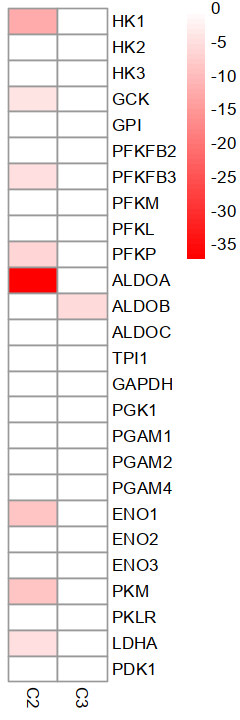

In [60]:
options(repr.plot.height=6,repr.plot.width=2)
pheatmap(glyco_data2[,c("C2","C3")],color =  colorRampPalette(c('red','white'))(50),legend = TRUE,
        # filename = "RNAseq_glycolysis.pdf",width = 2,height = 6,
          cluster_rows = F,cluster_cols = F)

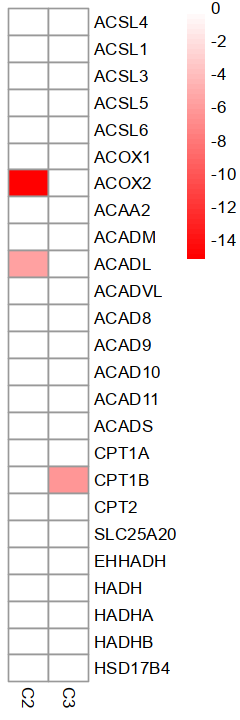

In [61]:
options(repr.plot.height=6,repr.plot.width=2)
pheatmap(fatty_data2[,c("C2","C3")],color =  colorRampPalette(c('red','white'))(50),legend = TRUE,
        # filename = "RNAseq_glycolysis.pdf",width = 2,height = 6,
          cluster_rows = F,cluster_cols = F)

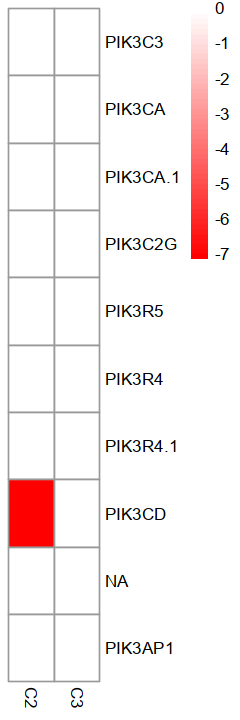

In [62]:
options(repr.plot.height=6,repr.plot.width=2)
pheatmap(pik_data2[,c("C2","C3")],color =  colorRampPalette(c('red','white'))(50),legend = TRUE,
        # filename = "RNAseq_glycolysis.pdf",width = 2,height = 6,
          cluster_rows = F,cluster_cols = F)

In [63]:
save.image('Deseq2_scprinterfootCluster.Rds')

In [7]:
load('Deseq2_scprinterfootCluster.Rds')



Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree



In [19]:
saveRDS(object = C2_KEGG[c('hsa00010','hsa00020','hsa00620','hsa01212','hsa05230','hsa00520'),]  %>% select(Description,geneID),file = "C2_KEGG.selectpathway.Rds")

In [37]:
openxlsx::write.xlsx(res$all,file="Glio_RNAseq.deseq2.xlsx",rowNames=TRUE)

In [49]:
openxlsx::write.xlsx(list(C2_GO = C2_GO,C3_GO = C3_GO),file="RNA-seq_GO.deseq2.xlsx",rowNames=TRUE)

In [50]:
openxlsx::write.xlsx(list(C2_KEGG = C2_KEGG,C3_KEGG = C3_KEGG),file="RNA-seq_KEGG.deseq2.xlsx",rowNames=TRUE)